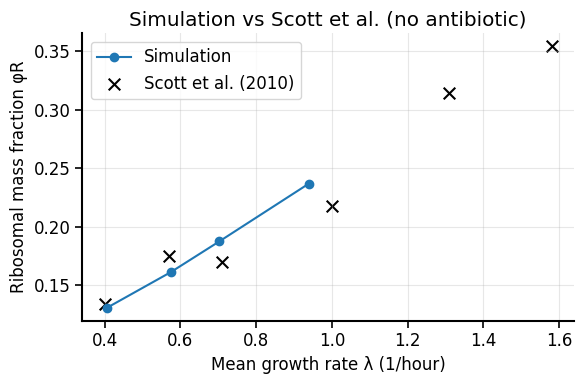

In [27]:
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.ipc as ipc
import matplotlib.pyplot as plt

# ===============================================================
# Files and constants
# ===============================================================
FILES = {
    0.45: "Data/ns045.arrow",
    0.74: "Data/ns074.arrow",
    1.03: "Data/ns103.arrow",
    1.76: "Data/ns176.arrow",
}

NR = 7549.0
NX = 300.0
GMAX = 12600.0
KGAMMA = 7 * 22000

BURN_IN = 1000.0          # minutes
MIN_TO_DLB = 60.0 / np.log(2.0)   # 1/min → doublings/hour

# ===============================================================
# Helpers
# ===============================================================
def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()

    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo_mass = NX * (q + et + em)
    total_mass = ribo_mass + non_ribo_mass

    return ribo_mass, total_mass

def compute_ttrate(df, mass):
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / ((KGAMMA * mass / 1e8) + a)

    active = (
        df["rmr(t)"].to_numpy()
        + df["rmt(t)"].to_numpy()
        + df["rmm(t)"].to_numpy()
        + df["rmq(t)"].to_numpy()
    )

    return active * gamma

# ===============================================================
# STORAGE FOR RESULTS
# ===============================================================
phiR_mean_all = []
lambda_mean_all = []
ns_values = []

# ===============================================================
# MAIN LOOP
# ===============================================================
for ns, fname in FILES.items():
    df = load_arrow(fname)
    t = df["timestamp"].to_numpy()

    ribo_mass, mass_full = compute_mass(df)
    ttrate = compute_ttrate(df, mass_full)

    # Growth rate in 1/hour
    lam = (ttrate / mass_full) * 60 #MIN_TO_DLB

    # Ribosomal mass fraction
    phiR = ribo_mass / mass_full

    # Burn-in
    mask = t >= BURN_IN
    lam = lam[mask]
    phiR = phiR[mask]

    # Remove NaNs
    valid = (~np.isnan(lam)) & (~np.isnan(phiR))
    lam = lam[valid]
    phiR = phiR[valid]

    # Store means
    ns_values.append(ns)
    lambda_mean_all.append(lam.mean())
    phiR_mean_all.append(phiR.mean())

# ===============================================================
# PLOT — Overlay with Scott et al. (no antibiotics)
# ===============================================================
scott = pd.read_csv("Data/Scott_Data.csv")
scott0 = scott[scott["cl"] == 0]

lambda_scott = scott0["lambda"].values * 60  # convert to in 1/hour
phiR_scott = scott0["fr"].values

plt.figure(figsize=(6, 4))

plt.plot(
    lambda_mean_all,
    phiR_mean_all,
    "o-",
    label="Simulation",
    color="tab:blue"
)

plt.scatter(
    lambda_scott,
    phiR_scott,
    color="black",
    s=70,
    marker="x",
    label="Scott et al. (2010)"
)

plt.xlabel("Mean growth rate λ (1/hour)")
plt.ylabel("Ribosomal mass fraction φR")
plt.title("Simulation vs Scott et al. (no antibiotic)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


KeyboardInterrupt: 

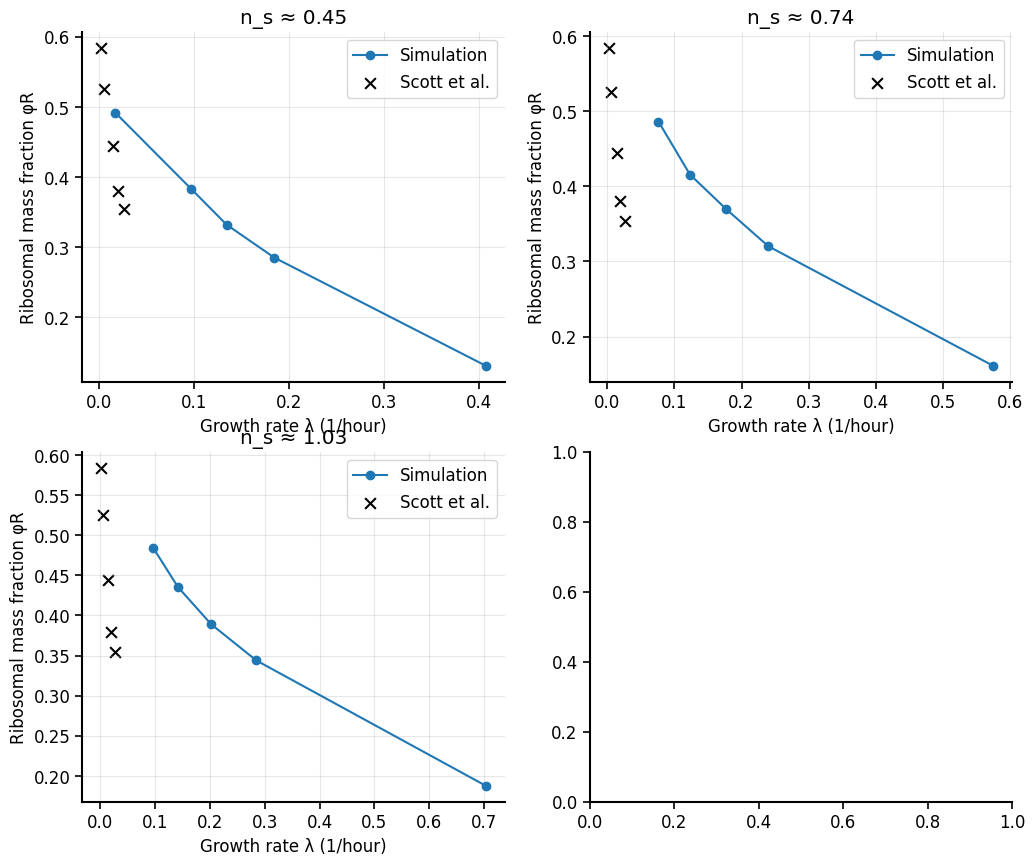

In [20]:
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.ipc as ipc
import matplotlib.pyplot as plt

# ===============================================================
# FILES
# ===============================================================
FILES = {
    (0.45, 0):  "Data/ns045.arrow",
    (0.45, 2):  "Data/ns045/abx2.arrow",
    (0.45, 4):  "Data/ns045/abx4.arrow",
    (0.45, 8):  "Data/ns045/abx8.arrow",
    (0.45,12):  "Data/ns045/abx12.arrow",

    (0.74, 0):  "Data/ns074.arrow",
    (0.74, 2):  "Data/ns074/abx2.arrow",
    (0.74, 4):  "Data/ns074/abx4.arrow",
    (0.74, 8):  "Data/ns074/abx8.arrow",
    (0.74,12):  "Data/ns074/abx12.arrow",

    (1.03, 0):  "Data/ns103.arrow",
    (1.03, 2):  "Data/ns103/abx2.arrow",
    (1.03, 4):  "Data/ns103/abx4.arrow",
    (1.03, 8):  "Data/ns103/abx8.arrow",
    (1.03,12):  "Data/ns103/abx12.arrow",

    (1.76, 0):  "Data/ns176.arrow",
    (1.76, 2):  "Data/ns176/abx2.arrow",
    (1.76, 4):  "Data/ns176/abx4.arrow",
    (1.76, 8):  "Data/ns176/abx8.arrow",
    (1.76,12):  "Data/ns176/abx12.arrow",
}

NS_VALUES  = sorted({k[0] for k in FILES})
ABX_LEVELS = [0, 2, 4, 8, 12]

# ===============================================================
# CONSTANTS (unchanged)
# ===============================================================
NR = 7549.0
NX = 300.0
GMAX = 12600.0
KGAMMA = 7 * 22000
BURN_IN = 1000.0

# ===============================================================
# HELPERS (unchanged)
# ===============================================================
def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()

    q  = df["q(t)"].to_numpy()
    et = df["et(t)"].to_numpy()
    em = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo_mass = NX * (q + et + em)

    return ribo_mass, non_ribo_mass, ribo_mass + non_ribo_mass

def compute_ttrate(df, mass):
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / ((KGAMMA * mass / 1e8) + a)

    active = (
        df["rmr(t)"].to_numpy()
        + df["rmt(t)"].to_numpy()
        + df["rmm(t)"].to_numpy()
        + df["rmq(t)"].to_numpy()
    )
    return active * gamma

# ===============================================================
# GEOMETRY: POINT → POLYLINE DISTANCE
# ===============================================================
def point_to_segment_distance(p, a, b):
    ap = p - a
    ab = b - a
    t = np.dot(ap, ab) / np.dot(ab, ab)
    t = np.clip(t, 0, 1)
    return np.linalg.norm(p - (a + t * ab))

def point_to_polyline_distance(p, polyline):
    return min(
        point_to_segment_distance(p, polyline[i], polyline[i+1])
        for i in range(len(polyline) - 1)
    )

# ===============================================================
# LOAD SCOTT DATA
# ===============================================================
scott = pd.read_csv("Data/Scott_Data.csv")
scott = scott.rename(columns={"lambda": "lam", "fr": "phiR"})

# ===============================================================
# MAIN ANALYSIS
# ===============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

results = []

for ax, ns in zip(axes, NS_VALUES):

    sim_means = []

    for abx in ABX_LEVELS:
        df = load_arrow(FILES[(ns, abx)])
        t = df["timestamp"].to_numpy()

        ribo_mass, non_ribo_mass, mass = compute_mass(df)
        ttrate = compute_ttrate(df, mass)

        lam = (ttrate / mass) * 60.0
        phiR = ribo_mass / mass

        mask = t >= BURN_IN
        lam = lam[mask]
        phiR = phiR[mask]

        sim_means.append((lam.mean(), phiR.mean()))

    sim_curve = np.array(sim_means)

    # Scott subset: closest ns
    scott_sub = scott.iloc[(scott["ns"] - ns).abs().argsort()[:5]]
    scott_pts = np.column_stack((scott_sub["lam"], scott_sub["phiR"]))

    # Least squares distance
    dists = [point_to_polyline_distance(p, sim_curve) for p in scott_pts]
    msd = np.mean(np.square(dists))

    baseline = scott_sub[scott_sub["cl"] == 0]["lam"].iloc[0] #* 60.0
    nmsd = msd / baseline**2

    results.append({"ns": ns, "MSD": msd, "nMSD": nmsd})

    # ================= PLOT =================
    ax.plot(sim_curve[:,0], sim_curve[:,1], "-o",
            label="Simulation", color="tab:blue")

    ax.scatter(scott_pts[:,0], scott_pts[:,1],
               color="black", marker="x", s=60,
               label="Scott et al.")

    ax.set_title(f"n_s ≈ {ns}")
    ax.set_xlabel("Growth rate λ (1/hour)")
    ax.set_ylabel("Ribosomal mass fraction φR")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

print(pd.DataFrame(results))


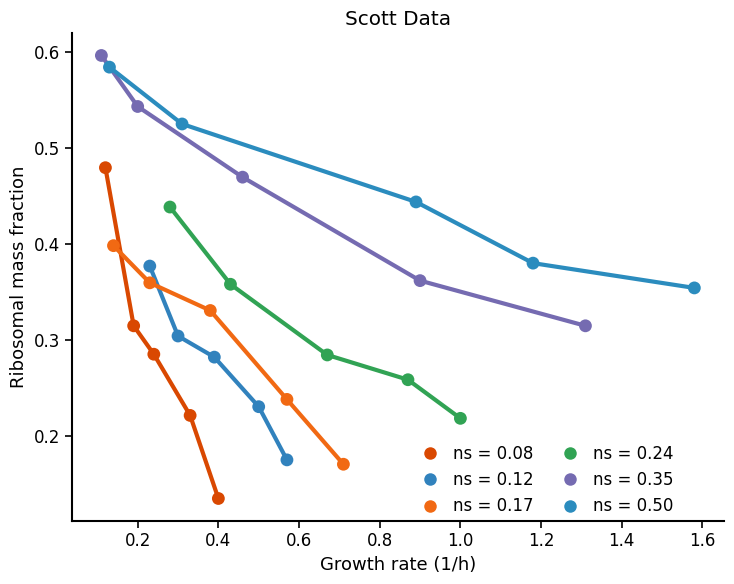

1.4426950408889634


In [29]:
# ============================================================
# Scott et al. data only
# Ribosomal mass fraction vs growth rate
# Nature-style visualization (NO error bars)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess
from matplotlib.lines import Line2D

# ------------------------------------------------------------
# GLOBAL STYLE (paper-like, unchanged)
# ------------------------------------------------------------
plt.rcParams.update({
    "font.size": 12,
    "axes.linewidth": 1.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.major.size": 5,
    "ytick.major.size": 5,
})

# ------------------------------------------------------------
# COLOR PALETTE (same as before)
# ------------------------------------------------------------
COLORS = [
    "#d94801",  # red-orange
    "#3182bd",  # blue
    "#f16913",  # orange
    "#31a354",  # green
    "#756bb1",  # purple
    "#2b8cbe",  # teal
]

# ------------------------------------------------------------
# LOAD SCOTT DATA
# ------------------------------------------------------------
scott = pd.read_csv("Data/Scott_Data.csv")

# Rename for clarity
scott = scott.rename(columns={
    "lambda": "lam",
    "fr": "phiR",
    "ns": "ns",
    "cl": "abx"
})

# Convert growth rate to 1/hour 
scott["lam"] = scott["lam"] * 60 #/ np.log(2.0)

# ------------------------------------------------------------
# LOWESS SMOOTHER
# ------------------------------------------------------------
def smooth_xy(x, y, frac=0.7):
    sm = lowess(y, x, frac=frac, return_sorted=True)
    return sm[:, 0], sm[:, 1]

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------
plt.figure(figsize=(7.5, 6))

legend_elements = []

for color, (ns, g) in zip(COLORS, scott.groupby("ns")):
    g = g.sort_values("lam")

    # Smooth curve
    xs, ys = smooth_xy(g["lam"], g["phiR"])
    plt.plot(xs, ys, color=color, lw=3)

    # Scatter points
    plt.scatter(
        g["lam"],
        g["phiR"],
        s=85,
        color=color,
        edgecolor="none",
        zorder=3
    )

    # Legend entry
    legend_elements.append(
        Line2D(
            [0], [0],
            marker='o',
            linestyle='None',
            markersize=9,
            markerfacecolor=color,
            markeredgecolor='none',
            label=f"ns = {ns:.2f}"
        )
    )

# ------------------------------------------------------------
# AXES & LEGEND
# ------------------------------------------------------------
plt.xlabel("Growth rate (1/h)", fontsize=13)
plt.ylabel("Ribosomal mass fraction", fontsize=13)
plt.title("Scott Data")

plt.legend(
    handles=legend_elements,
    frameon=False,
    ncol=2,
    columnspacing=1.2,
    handletextpad=0.4,
    loc="lower left",
    bbox_to_anchor=(0.5, -0.02)
)

plt.tight_layout()
plt.show()
print(1/np.log(2.0))

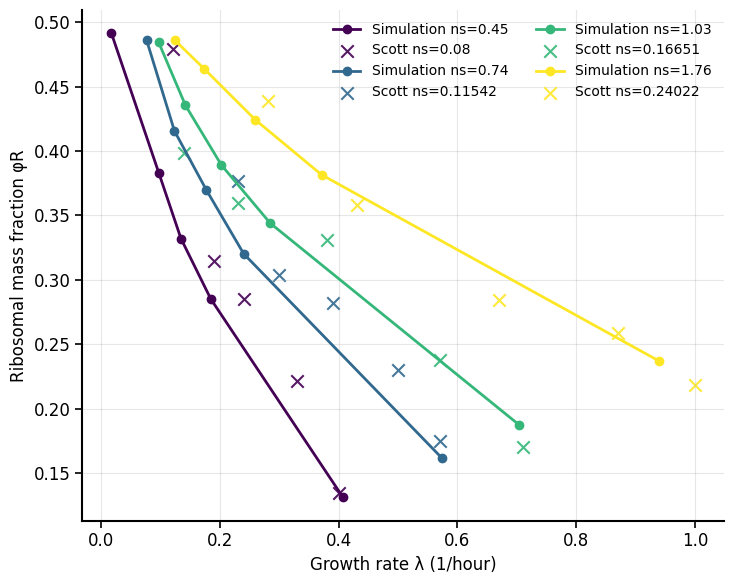

In [39]:
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.ipc as ipc
import matplotlib.pyplot as plt

# ===============================================================
# FILES
# ===============================================================
FILES = {
    (0.45, 0):  "Data/ns045.arrow",
    (0.45, 2):  "Data/ns045/abx2.arrow",
    (0.45, 4):  "Data/ns045/abx4.arrow",
    (0.45, 8):  "Data/ns045/abx8.arrow",
    (0.45,12):  "Data/ns045/abx12.arrow",

    (0.74, 0):  "Data/ns074.arrow",
    (0.74, 2):  "Data/ns074/abx2.arrow",
    (0.74, 4):  "Data/ns074/abx4.arrow",
    (0.74, 8):  "Data/ns074/abx8.arrow",
    (0.74,12):  "Data/ns074/abx12.arrow",

    (1.03, 0):  "Data/ns103.arrow",
    (1.03, 2):  "Data/ns103/abx2.arrow",
    (1.03, 4):  "Data/ns103/abx4.arrow",
    (1.03, 8):  "Data/ns103/abx8.arrow",
    (1.03,12):  "Data/ns103/abx12.arrow",

    (1.76, 0):  "Data/ns176.arrow",
    (1.76, 2):  "Data/ns176/abx2.arrow",
    (1.76, 4):  "Data/ns176/abx4.arrow",
    (1.76, 8):  "Data/ns176/abx8.arrow",
    (1.76,12):  "Data/ns176/abx12.arrow",
}

NS_VALUES  = sorted({k[0] for k in FILES})
ABX_LEVELS = [0, 2, 4, 8, 12]

# ===============================================================
# CONSTANTS (unchanged)
# ===============================================================
NR = 7549.0
NX = 300.0
GMAX = 12600.0
KGAMMA = 7 * 22000
BURN_IN = 1000.0

# ===============================================================
# HELPERS (unchanged)
# ===============================================================
def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()

    q  = df["q(t)"].to_numpy()
    et = df["et(t)"].to_numpy()
    em = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo_mass = NX * (q + et + em)

    return ribo_mass, non_ribo_mass, ribo_mass + non_ribo_mass

def compute_ttrate(df, mass):
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / ((KGAMMA * mass / 1e8) + a)

    active = (
        df["rmr(t)"].to_numpy()
        + df["rmt(t)"].to_numpy()
        + df["rmm(t)"].to_numpy()
        + df["rmq(t)"].to_numpy()
    )
    return active * gamma

# ===============================================================
# GEOMETRY: POINT → POLYLINE DISTANCE
# ===============================================================
def point_to_segment_distance(p, a, b):
    ap = p - a
    ab = b - a
    t = np.dot(ap, ab) / np.dot(ab, ab)
    t = np.clip(t, 0, 1)
    return np.linalg.norm(p - (a + t * ab))

def point_to_polyline_distance(p, polyline):
    return min(
        point_to_segment_distance(p, polyline[i], polyline[i+1])
        for i in range(len(polyline) - 1)
    )

# ===============================================================
# LOAD SCOTT DATA
# ===============================================================
scott = pd.read_csv("Data/Scott_Data.csv")
scott = scott.rename(columns={"lambda": "lam", "fr": "phiR"})

# ===============================================================
# ONE-PANEL: All simulation ns + all Scott data
# ===============================================================

plt.figure(figsize=(7.5, 6))
# Explicit mapping between simulation and Scott nutrient strengths
# (simulation ns → Scott ns)
NS_MAP = {
    0.45: 0.08,
    0.74: 0.11542,
    1.03: 0.16651,
    1.76: 0.24022,
}


COLORS = plt.cm.viridis(np.linspace(0, 1, len(NS_MAP)))

for color, (ns_sim, ns_scott) in zip(COLORS, NS_MAP.items()):

    # ---- Simulation curve ----
    sim_means = []
    for abx in ABX_LEVELS:
        df = load_arrow(FILES[(ns_sim, abx)])
        t = df["timestamp"].to_numpy()

        ribo_mass, non_ribo_mass, mass = compute_mass(df)
        ttrate = compute_ttrate(df, mass)

        lam = (ttrate / mass) * 60.0   # 1/hour
        phiR = ribo_mass / mass

        mask = t >= BURN_IN
        sim_means.append((lam[mask].mean(), phiR[mask].mean()))

    sim_curve = np.array(sim_means)

    plt.plot(
        sim_curve[:, 0],
        sim_curve[:, 1],
        "-o",
        color=color,
        lw=2,
        label=f"Simulation ns={ns_sim:.2f}"
    )

    # ---- Corresponding Scott points (all cl) ----
    scott_sub = scott[scott["ns"] == ns_scott]

    plt.scatter(
        scott_sub["lam"]*60,
        scott_sub["phiR"],
        marker="x",
        s=80,
        color=color,
        alpha=0.9,
        label=f"Scott ns={ns_scott}"
    )

# ---- Axes & legend ----
plt.xlabel("Growth rate λ (1/hour)")
plt.ylabel("Ribosomal mass fraction φR")
plt.grid(alpha=0.3)

plt.legend(
    frameon=False,
    ncol=2,
    fontsize=10
)

plt.tight_layout()
plt.show()


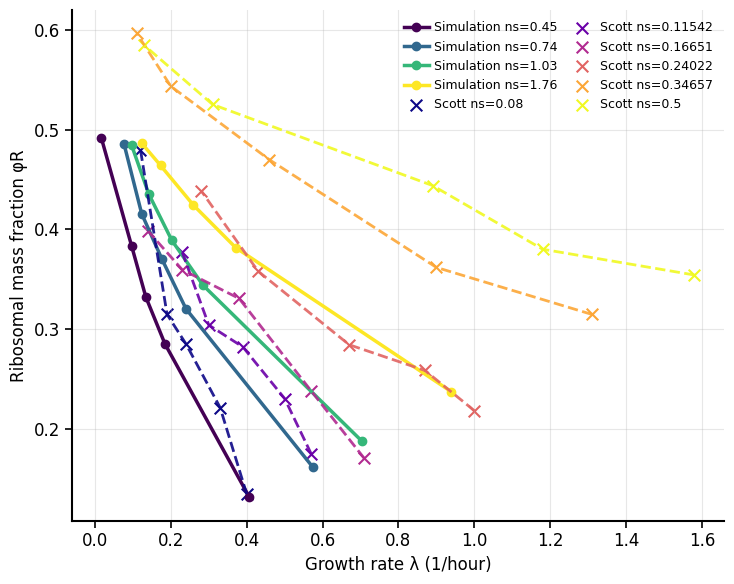

In [ ]:
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.ipc as ipc
import matplotlib.pyplot as plt

# ===============================================================
# FILES
# ===============================================================
FILES = {
    (0.45, 0):  "Data/ns045.arrow",
    (0.45, 2):  "Data/ns045/abx2.arrow",
    (0.45, 4):  "Data/ns045/abx4.arrow",
    (0.45, 8):  "Data/ns045/abx8.arrow",
    (0.45,12):  "Data/ns045/abx12.arrow",

    (0.74, 0):  "Data/ns074.arrow",
    (0.74, 2):  "Data/ns074/abx2.arrow",
    (0.74, 4):  "Data/ns074/abx4.arrow",
    (0.74, 8):  "Data/ns074/abx8.arrow",
    (0.74,12):  "Data/ns074/abx12.arrow",

    (1.03, 0):  "Data/ns103.arrow",
    (1.03, 2):  "Data/ns103/abx2.arrow",
    (1.03, 4):  "Data/ns103/abx4.arrow",
    (1.03, 8):  "Data/ns103/abx8.arrow",
    (1.03,12):  "Data/ns103/abx12.arrow",

    (1.76, 0):  "Data/ns176.arrow",
    (1.76, 2):  "Data/ns176/abx2.arrow",
    (1.76, 4):  "Data/ns176/abx4.arrow",
    (1.76, 8):  "Data/ns176/abx8.arrow",
    (1.76,12):  "Data/ns176/abx12.arrow",
}

NS_VALUES  = sorted({k[0] for k in FILES})
ABX_LEVELS = [0, 2, 4, 8, 12]

# ===============================================================
# CONSTANTS (unchanged)
# ===============================================================
NR = 7549.0
NX = 300.0
GMAX = 12600.0
KGAMMA = 7 * 22000
BURN_IN = 1000.0

# ===============================================================
# HELPERS (unchanged)
# ===============================================================
def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()

    q  = df["q(t)"].to_numpy()
    et = df["et(t)"].to_numpy()
    em = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo_mass = NX * (q + et + em)

    return ribo_mass, non_ribo_mass, ribo_mass + non_ribo_mass

def compute_ttrate(df, mass):
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / ((KGAMMA * mass / 1e8) + a)

    active = (
        df["rmr(t)"].to_numpy()
        + df["rmt(t)"].to_numpy()
        + df["rmm(t)"].to_numpy()
        + df["rmq(t)"].to_numpy()
    )
    return active * gamma

# ===============================================================
# GEOMETRY: POINT → POLYLINE DISTANCE
# ===============================================================
def point_to_segment_distance(p, a, b):
    ap = p - a
    ab = b - a
    t = np.dot(ap, ab) / np.dot(ab, ab)
    t = np.clip(t, 0, 1)
    return np.linalg.norm(p - (a + t * ab))

def point_to_polyline_distance(p, polyline):
    return min(
        point_to_segment_distance(p, polyline[i], polyline[i+1])
        for i in range(len(polyline) - 1)
    )

# ===============================================================
# LOAD SCOTT DATA
# ===============================================================
scott = pd.read_csv("Data/Scott_Data.csv")
scott = scott.rename(columns={"lambda": "lam", "fr": "phiR"})

# ===============================================================
# ONE-PANEL: All simulation ns + all Scott data
# ===============================================================
# Simulation colours
SIM_COLORS = plt.cm.viridis(np.linspace(0, 1, len(NS_MAP)))

# Scott colours (distinct palette)
SCOTT_COLORS = plt.cm.plasma(np.linspace(0, 1, 6))
plt.figure(figsize=(7.5, 6))

for color, ns_sim in zip(SIM_COLORS, NS_MAP.keys()):

    sim_means = []
    for abx in ABX_LEVELS:
        df = load_arrow(FILES[(ns_sim, abx)])
        t = df["timestamp"].to_numpy()

        ribo_mass, _, mass = compute_mass(df)
        ttrate = compute_ttrate(df, mass)

        lam = (ttrate / mass) * 60.0  # 1/hour
        phiR = ribo_mass / mass

        mask = t >= BURN_IN
        sim_means.append((lam[mask].mean(), phiR[mask].mean()))

    sim_curve = np.array(sim_means)

    plt.plot(
        sim_curve[:, 0],
        sim_curve[:, 1],
        "-o",
        lw=2.5,
        color=color,
        label=f"Simulation ns={ns_sim:.2f}"
    )
    
# Plot ALL Scott ns values (not just those in NS_MAP)
SCOTT_NS = sorted(scott["ns"].unique())
SCOTT_COLORS = plt.cm.plasma(np.linspace(0, 1, len(SCOTT_NS)))

for color, ns_scott in zip(SCOTT_COLORS, SCOTT_NS):

    scott_sub = scott[scott["ns"] == ns_scott].sort_values("cl")

    plt.plot(
        scott_sub["lam"] * 60,    
        scott_sub["phiR"],
        linestyle="--",
        lw=2,
        color=color,
        alpha=0.9
    )

    plt.scatter(
        scott_sub["lam"] * 60,
        scott_sub["phiR"],
        marker="x",
        s=70,
        color=color,
        label=f"Scott ns={ns_scott}"
    )

plt.xlabel("Growth rate λ (1/hour)")
plt.ylabel("Ribosomal mass fraction φR")
plt.grid(alpha=0.3)

plt.legend(
    frameon=False,
    fontsize=9,
    ncol=2,
    columnspacing=1.0,
    handletextpad=0.4
)

plt.tight_layout()
plt.show()
